# Policy Gradient Demo: From Discrete to Continuous Actions

**Recap from the previous notebook (`demo_crawler_rl.ipynb`):**

| Demo | Method | Result |
|------|--------|--------|
| 0 | Value Iteration | Barely works — needs model + correct state |
| 1 | Tabular Q (2D) | Works on coarse state |
| 2 | Tabular Q (4D) | Breaks — curse of dimensionality |
| 3 | DQN (4 actions) | Works with continuous state |
| 4 | DQN (121 actions) | **Breaks** — can't scale to continuous actions |

**The problem:** DQN picks actions via `argmax` over Q-values — impossible when actions are continuous.

**The fix:** Instead of learning Q-values and deriving a policy, **directly parametrize and optimize the policy**.

$$\pi_\theta(a|s) \rightarrow a \in \mathbb{R}^n$$

This notebook implements **REINFORCE** and **Actor-Critic** on the same 2D crawler, now with **continuous torque output**.

In [1]:
# Setup - run this first
!pip install -q mujoco

import numpy as np
import mujoco
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import time
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

print(f'MuJoCo version: {mujoco.__version__}')
print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Setup complete!')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
MuJoCo version: 3.6.0
PyTorch version: 2.11.0
Device: cpu
Setup complete!


In [2]:
# ============================================================
# Crawler Environment (same as demo_crawler_rl.ipynb)
# ============================================================

CRAWLER_XML = """
<mujoco model="crawler2d">
  <compiler angle="degree" inertiafromgeom="true"/>
  <option timestep="0.005" gravity="0 0 -9.81" integrator="RK4"/>

  <default>
    <geom conaffinity="1" condim="3" friction="1.5 0.5 0.1" density="1000"/>
    <joint armature="0.1" damping="0.5"/>
  </default>

  <asset>
    <texture type="2d" name="grid" builtin="checker" width="512" height="512"
             rgb1="0.7 0.9 0.7" rgb2="0.6 0.85 0.6"/>
    <material name="grid" texture="grid" texrepeat="8 8"/>
  </asset>

  <worldbody>
    <light diffuse="0.8 0.8 0.8" pos="0 -2 3" dir="0 0.5 -1"/>
    <geom name="floor" type="plane" size="50 1 0.1" material="grid"/>

    <geom name="origin" type="box" size="0.01 0.15 0.002" pos="0 0 0.001" rgba="0.1 0.1 0.8 0.7" contype="0" conaffinity="0"/>
    <geom name="ruler_m4" type="box" size="0.006 0.12 0.002" pos="-2.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_m3" type="box" size="0.003 0.08 0.001" pos="-1.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_m2" type="box" size="0.006 0.12 0.002" pos="-1.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_m1" type="box" size="0.003 0.08 0.001" pos="-0.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_1" type="box" size="0.003 0.08 0.001" pos="0.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_2" type="box" size="0.006 0.12 0.002" pos="1.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_3" type="box" size="0.003 0.08 0.001" pos="1.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_4" type="box" size="0.006 0.12 0.002" pos="2.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_5" type="box" size="0.003 0.08 0.001" pos="2.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_6" type="box" size="0.006 0.12 0.002" pos="3.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_7" type="box" size="0.003 0.08 0.001" pos="3.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_8" type="box" size="0.006 0.12 0.002" pos="4.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_9" type="box" size="0.003 0.08 0.001" pos="4.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_10" type="box" size="0.006 0.12 0.002" pos="5.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_11" type="box" size="0.003 0.08 0.001" pos="5.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_12" type="box" size="0.006 0.12 0.002" pos="6.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_13" type="box" size="0.003 0.08 0.001" pos="6.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_14" type="box" size="0.006 0.12 0.002" pos="7.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_15" type="box" size="0.003 0.08 0.001" pos="7.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_16" type="box" size="0.006 0.12 0.002" pos="8.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_17" type="box" size="0.003 0.08 0.001" pos="8.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_18" type="box" size="0.006 0.12 0.002" pos="9.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_19" type="box" size="0.003 0.08 0.001" pos="9.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_20" type="box" size="0.006 0.12 0.002" pos="10.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>

    <camera name="side" pos="0 -0.8 0.25" xyaxes="1 0 0 0 0.3 1" mode="trackcom"/>

    <body name="torso" pos="0 0 0.035">
      <joint name="root_x" type="slide" axis="1 0 0"/>
      <joint name="root_z" type="slide" axis="0 0 1"/>
      <joint name="root_rot" type="hinge" axis="0 1 0"/>

      <geom name="torso_geom" type="box" size="0.08 0.035 0.025"
            rgba="0.3 0.75 0.3 1" density="3000"/>

      <body name="arm" pos="0.08 0 0.01">
        <joint name="arm_joint" type="hinge" axis="0 1 0"
               range="-70 70" limited="true"/>
        <geom name="arm_geom" type="capsule" size="0.012"
              fromto="0 0 0 0.12 0 0" rgba="0.95 0.7 0.1 1"/>

        <body name="hand" pos="0.12 0 0">
          <joint name="hand_joint" type="hinge" axis="0 1 0"
                 range="-70 70" limited="true"/>
          <geom name="hand_geom" type="capsule" size="0.008"
                fromto="0 0 0 0.08 0 0" rgba="0.9 0.15 0.15 1"/>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor name="arm_motor" joint="arm_joint" ctrllimited="true"
           ctrlrange="-1 1" gear="5"/>
    <motor name="hand_motor" joint="hand_joint" ctrllimited="true"
           ctrlrange="-1 1" gear="3"/>
  </actuator>
</mujoco>
"""


class CrawlerEnv:
    """2D MuJoCo crawler with 2 actuated joints.

    State:  4D continuous (arm angle, hand angle, arm vel, hand vel)
    Action: 2D continuous torque in [-1, 1]
    Reward: forward (x) velocity
    """

    def __init__(self, max_steps=500, frame_skip=4):
        self.model = mujoco.MjModel.from_xml_string(CRAWLER_XML)
        self.data = mujoco.MjData(self.model)
        self.max_steps = max_steps
        self.frame_skip = frame_skip
        self.steps = 0
        self.obs_dim = 4
        self.act_dim = 2

    def get_obs(self):
        arm_a, hand_a = self.data.qpos[3], self.data.qpos[4]
        arm_v, hand_v = self.data.qvel[3], self.data.qvel[4]
        return np.array([arm_a, hand_a, arm_v, hand_v], dtype=np.float32)

    def reset(self):
        mujoco.mj_resetData(self.model, self.data)
        self.data.qpos[3] = np.random.uniform(-0.1, 0.1)
        self.data.qpos[4] = np.random.uniform(-0.1, 0.1)
        mujoco.mj_forward(self.model, self.data)
        self.steps = 0
        return self.get_obs()

    def step(self, ctrl):
        x_before = self.data.qpos[0]
        self.data.ctrl[:] = np.clip(ctrl, -1, 1)
        for _ in range(self.frame_skip):
            mujoco.mj_step(self.model, self.data)
        x_after = self.data.qpos[0]
        dt = self.frame_skip * self.model.opt.timestep
        reward = (x_after - x_before) / dt
        self.steps += 1
        truncated = self.steps >= self.max_steps
        return self.get_obs(), reward, False, truncated, {'x': x_after}


print(f'Environment: obs_dim={CrawlerEnv().obs_dim}, act_dim={CrawlerEnv().act_dim}')
print('Actions are now CONTINUOUS 2D torques in [-1, 1] -- no more discrete action table!')

Environment: obs_dim=4, act_dim=2
Actions are now CONTINUOUS 2D torques in [-1, 1] -- no more discrete action table!


In [3]:
# ============================================================
# Visualization helpers (same as previous notebook)
# ============================================================

eval_results = {}


def render_episode(env, policy_fn, max_steps=500, cam_name='side'):
    """Roll out a policy. Returns (frames, distance, total_reward)."""
    renderer = mujoco.Renderer(env.model, height=320, width=560)
    frames = []
    obs = env.reset()
    total_reward = 0
    for _ in range(max_steps):
        renderer.update_scene(env.data, camera=cam_name)
        frames.append(renderer.render().copy())
        ctrl = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(ctrl)
        total_reward += reward
        if terminated or truncated:
            break
    dist = float(env.data.qpos[0])
    renderer.close()
    return frames, dist, total_reward


def eval_policy(env, policy_fn, label, max_steps=500):
    """Run a 10s rollout, render video, print distance, store result."""
    frames, dist, total_reward = render_episode(env, policy_fn, max_steps=max_steps)
    print(f'{label}: traveled {dist:.2f}m in 10s  (episode reward: {total_reward:.1f})')
    eval_results[label] = dist
    return frames, dist, total_reward


def show_video(frames, fps=30, title=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    if title:
        ax.set_title(title, fontsize=14)
    ax.axis('off')
    im = ax.imshow(frames[0])
    def update(i):
        im.set_data(frames[i])
        return [im]
    anim = animation.FuncAnimation(fig, update, frames=len(frames),
                                   interval=1000/fps, blit=True)
    plt.close()
    return HTML(anim.to_html5_video())


def plot_rewards(rewards, window=50, title='Training Progress', ax=None, color='steelblue', label=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(rewards, alpha=0.15, color=color)
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), smoothed, color=color, linewidth=2, label=label)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax


def plot_eval_comparison(results_dict, title='Policy Comparison: Distance Traveled in 10s'):
    labels = list(results_dict.keys())
    dists = list(results_dict.values())
    colors = ['#d9534f' if d < 0.5 else '#5bc0de' if d < 1.5 else '#5cb85c' for d in dists]

    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.5 + 1)))
    bars = ax.barh(labels, dists, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('Distance (m)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    for bar, d in zip(bars, dists):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{d:.2f}m', va='center', fontsize=11)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

In [5]:
# ============================================================
# Load the DQN reference policy from the previous notebook
# ============================================================

class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x):
        return self.net(x)

# Load saved checkpoint
ckpt_path = 'saved_policies/dqn_crawler_4act.pt'
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    dqn_ref = QNetwork(ckpt['obs_dim'], ckpt['n_actions'], ckpt['hidden']).to(device)
    dqn_ref.load_state_dict(ckpt['q_net_state_dict'])
    dqn_ref.eval()
    ACTIONS_4 = {int(k): np.array(v) for k, v in ckpt['action_map'].items()}
    print(f'Loaded DQN reference policy from {ckpt_path}')

    # Evaluate the DQN reference
    env_ref = CrawlerEnv()
    def dqn_ref_policy(obs):
        with torch.no_grad():
            q = dqn_ref(torch.FloatTensor(obs).unsqueeze(0).to(device))
            return ACTIONS_4[q.argmax(dim=1).item()]

    frames_ref, dist_ref, _ = eval_policy(env_ref, dqn_ref_policy, 'DQN (4 discrete, reference)')
    show_video(frames_ref, title=f'DQN reference — {dist_ref:.2f}m in 10s')
else:
    print(f'No saved DQN policy found at {ckpt_path}.')
    print('Run demo_crawler_rl.ipynb first, or continue without the reference.')
    dist_ref = None

No saved DQN policy found at saved_policies/dqn_crawler_4act.pt.
Run demo_crawler_rl.ipynb first, or continue without the reference.


---
## Demo 5: REINFORCE with continuous actions

DQN broke because it needs `argmax` over all actions. **Policy gradient** sidesteps this entirely:
- The policy network **directly outputs** continuous torques
- We parametrize a **Gaussian distribution** over actions: the network outputs the mean $\mu(s)$, and we sample $a \sim \mathcal{N}(\mu(s), \sigma^2)$
- Training: collect full episodes, then **increase the probability of actions that led to high reward**

This is the **REINFORCE** algorithm (Williams, 1992):

$$\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

where $G_t = \sum_{t'=t}^{T} \gamma^{t'-t} r_{t'}$ is the return from timestep $t$.

**Same crawler, same 4D state — but now with continuous 2D torque output.**

In [6]:
# ============================================================
# REINFORCE (Vanilla Policy Gradient)
# ============================================================

class GaussianPolicy(nn.Module):
    """Policy network that outputs mean of a Gaussian. std is a learnable parameter."""
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, act_dim), nn.Tanh()  # output in [-1, 1]
        )
        # Learnable log-std (start at log(0.5) ≈ -0.69)
        self.log_std = nn.Parameter(torch.full((act_dim,), -0.7))

    def forward(self, obs):
        mu = self.net(obs)
        std = self.log_std.exp()
        return mu, std

    def get_action(self, obs):
        """Sample an action and return (action, log_prob)."""
        mu, std = self.forward(obs)
        dist = Normal(mu, std)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        return action.clamp(-1, 1), log_prob

    def evaluate(self, obs, actions):
        """Compute log_prob of given actions (for batched computation)."""
        mu, std = self.forward(obs)
        dist = Normal(mu, std)
        return dist.log_prob(actions).sum(dim=-1)


def train_reinforce(env, n_episodes=500, gamma=0.99, lr=3e-4, hidden=64,
                    verbose=True, seed=None):
    """Train REINFORCE. Returns (policy, rewards_list)."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    policy = GaussianPolicy(env.obs_dim, env.act_dim, hidden).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    rewards_history = []

    t0 = time.time()
    for ep in range(n_episodes):
        # Collect one episode
        obs = env.reset()
        log_probs = []
        rewards = []

        while True:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob = policy.get_action(obs_t)
            act_np = action.squeeze(0).cpu().detach().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(act_np)
            log_probs.append(log_prob)
            rewards.append(reward)
            obs = next_obs
            if terminated or truncated:
                break

        # Compute returns G_t = sum of discounted future rewards
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns).to(device)

        # Normalize returns (helps with training stability)
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Policy gradient update
        log_probs_t = torch.stack(log_probs).squeeze()
        loss = -(log_probs_t * returns).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        rewards_history.append(total_reward)

        if verbose and (ep + 1) % 100 == 0:
            avg = np.mean(rewards_history[-50:])
            std_val = policy.log_std.exp().mean().item()
            print(f'  Episode {ep+1:4d} | Avg reward: {avg:7.1f} | std: {std_val:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    return policy, rewards_history

In [7]:
# ---------- Demo 5: REINFORCE on the crawler ----------
print('=== Demo 5: REINFORCE with continuous actions ===')
print(f'State: 4D continuous (arm angle, hand angle, arm vel, hand vel)')
print(f'Actions: 2D CONTINUOUS torques in [-1, 1]')
print(f'Policy: Gaussian (neural net outputs mean, learnable std)\n')

env_pg = CrawlerEnv()
policy_reinforce, rewards_reinforce = train_reinforce(env_pg, n_episodes=500, lr=3e-4)

=== Demo 5: REINFORCE with continuous actions ===
State: 4D continuous (arm angle, hand angle, arm vel, hand vel)
Actions: 2D CONTINUOUS torques in [-1, 1]
Policy: Gaussian (neural net outputs mean, learnable std)

  Episode  100 | Avg reward:     0.6 | std: 0.496
  Episode  200 | Avg reward:    16.7 | std: 0.497
  Episode  300 | Avg reward:    34.4 | std: 0.495
  Episode  400 | Avg reward:    37.2 | std: 0.494
  Episode  500 | Avg reward:    38.2 | std: 0.492
  Training completed in 44.8s


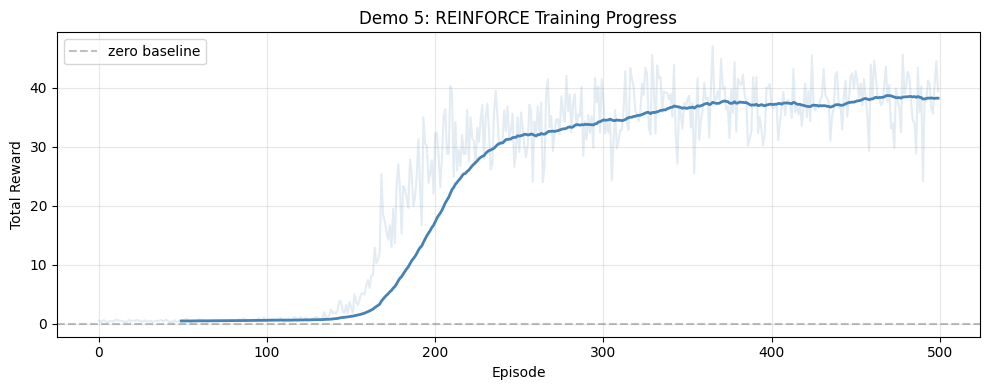


Final avg reward (last 50 episodes): 38.2
Note: actions are CONTINUOUS — no discretization needed!


In [8]:
# Training curve
fig, ax = plt.subplots(figsize=(10, 4))
plot_rewards(rewards_reinforce, title='Demo 5: REINFORCE Training Progress', ax=ax)
ax.axhline(y=0, color='gray', ls='--', alpha=0.5, label='zero baseline')
if dist_ref is not None:
    ax.axhline(y=np.mean(rewards_reinforce[-50:]), color='tab:green', ls=':', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nFinal avg reward (last 50 episodes): {np.mean(rewards_reinforce[-50:]):.1f}')
print(f'Note: actions are CONTINUOUS — no discretization needed!')

In [10]:
# 10-second rollout of the REINFORCE policy
env_eval = CrawlerEnv()

def reinforce_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = policy_reinforce(obs_t)
        return mu.squeeze(0).cpu().numpy()

frames_pg, dist_pg, _ = eval_policy(env_eval, reinforce_policy, 'Demo 5: REINFORCE')
show_video(frames_pg, title=f'REINFORCE — {dist_pg:.2f}m in 10s (continuous actions!)')

Demo 5: REINFORCE: traveled 0.61m in 10s  (episode reward: 30.6)


---
## Demo 6: The variance problem

REINFORCE works — but look at how **noisy** the training curves are! This is because:

1. **High variance gradient estimates:** Each gradient is based on a *single episode* (one sample of many possible trajectories)
2. **Credit assignment:** The return $G_t$ credits early actions for all future rewards, even if those rewards were due to later actions
3. **Learning rate sensitivity:** Too high → unstable, too low → no learning

Let's see this concretely: train **5 independent runs** with the same hyperparameters but different random seeds.

In [11]:
# ---------- Demo 6: Variance across runs ----------
print('=== Demo 6: REINFORCE variance — 5 seeds, same hyperparameters ===\n')

n_seeds = 5
seed_rewards = {}
for seed in range(n_seeds):
    print(f'--- Seed {seed} ---')
    env_seed = CrawlerEnv()
    _, rews = train_reinforce(env_seed, n_episodes=500, lr=3e-4, seed=seed, verbose=True)
    seed_rewards[seed] = rews
    print()

=== Demo 6: REINFORCE variance — 5 seeds, same hyperparameters ===

--- Seed 0 ---
  Episode  100 | Avg reward:    16.4 | std: 0.497
  Episode  200 | Avg reward:    23.2 | std: 0.495
  Episode  300 | Avg reward:    24.4 | std: 0.494
  Episode  400 | Avg reward:    24.8 | std: 0.493
  Episode  500 | Avg reward:    25.2 | std: 0.490
  Training completed in 42.0s

--- Seed 1 ---
  Episode  100 | Avg reward:     0.6 | std: 0.496
  Episode  200 | Avg reward:     0.8 | std: 0.498
  Episode  300 | Avg reward:    17.8 | std: 0.497
  Episode  400 | Avg reward:    36.2 | std: 0.496
  Episode  500 | Avg reward:    38.3 | std: 0.495
  Training completed in 42.6s

--- Seed 2 ---
  Episode  100 | Avg reward:     0.0 | std: 0.497
  Episode  200 | Avg reward:     0.2 | std: 0.497
  Episode  300 | Avg reward:     0.5 | std: 0.499
  Episode  400 | Avg reward:     0.5 | std: 0.500
  Episode  500 | Avg reward:     1.1 | std: 0.502
  Training completed in 45.3s

--- Seed 3 ---
  Episode  100 | Avg reward: 

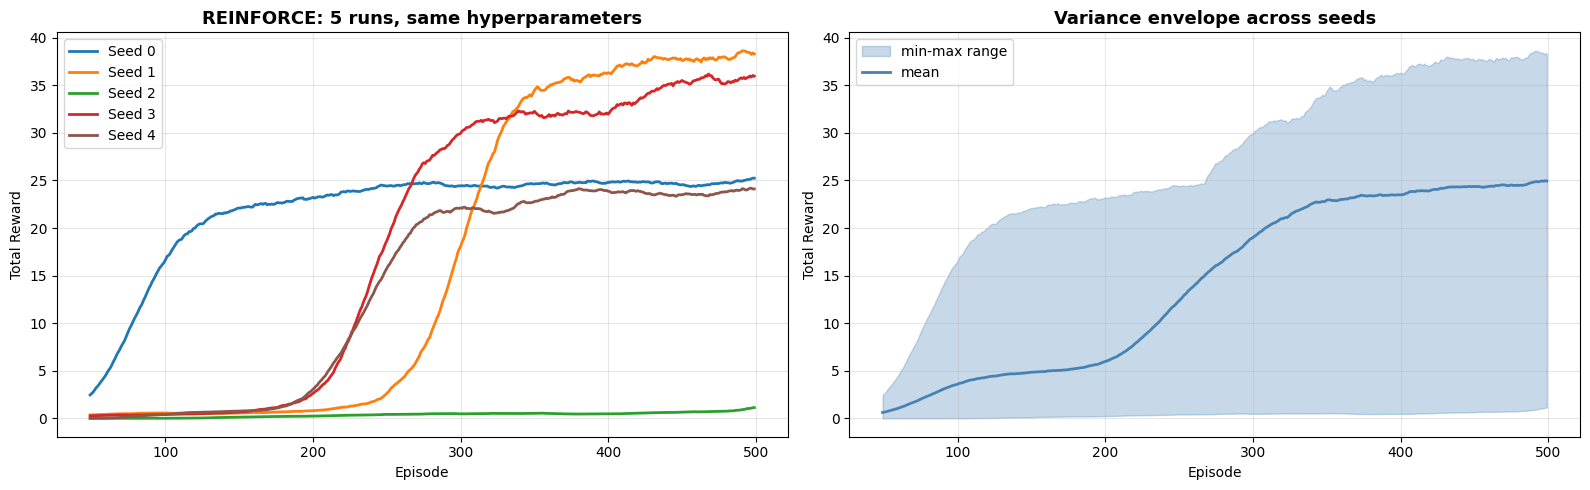

Final avg reward across seeds: 24.9 +/- 13.2
Best seed: 38.3, Worst seed: 1.1

The wide spread shows HIGH VARIANCE — a fundamental problem with vanilla REINFORCE.
Fix: subtract a BASELINE from the returns to reduce variance without adding bias.


In [12]:
# Overlay all 5 training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: all curves overlaid
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 0.5, n_seeds))
window = 50
for seed, (s, rews) in enumerate(seed_rewards.items()):
    if len(rews) >= window:
        smoothed = np.convolve(rews, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rews)), smoothed, color=colors[seed],
                linewidth=2, label=f'Seed {s}')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('REINFORCE: 5 runs, same hyperparameters', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: spread (min/max/mean envelope)
ax = axes[1]
min_len = min(len(r) for r in seed_rewards.values())
all_rewards = np.array([r[:min_len] for r in seed_rewards.values()])
# Smooth each run
smoothed_all = np.array([np.convolve(r, np.ones(window)/window, mode='valid')
                         for r in all_rewards])
x = np.arange(window-1, min_len)
mean_r = smoothed_all.mean(axis=0)
min_r = smoothed_all.min(axis=0)
max_r = smoothed_all.max(axis=0)
ax.fill_between(x, min_r, max_r, alpha=0.3, color='steelblue', label='min-max range')
ax.plot(x, mean_r, color='steelblue', linewidth=2, label='mean')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Variance envelope across seeds', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_rewards = [np.mean(r[-50:]) for r in seed_rewards.values()]
print(f'Final avg reward across seeds: {np.mean(final_rewards):.1f} +/- {np.std(final_rewards):.1f}')
print(f'Best seed: {np.max(final_rewards):.1f}, Worst seed: {np.min(final_rewards):.1f}')
print()
print('The wide spread shows HIGH VARIANCE — a fundamental problem with vanilla REINFORCE.')
print('Fix: subtract a BASELINE from the returns to reduce variance without adding bias.')

---
## Demo 7: REINFORCE with baseline (Actor-Critic)

The key insight: if we subtract a **baseline** $b(s_t)$ from the returns, the gradient is still unbiased but has lower variance:

$$\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_{t} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot (G_t - b(s_t))\right]$$

The best baseline is $b(s_t) = V^\pi(s_t)$ — the **expected return from state $s_t$**. The difference $G_t - V(s_t)$ is the **advantage**: *"how much better was this action than what we'd expect on average?"*

This gives us the **Actor-Critic** architecture:
- **Actor** $\pi_\theta(a|s)$: the policy network (same as before)
- **Critic** $V_\phi(s)$: a value network that estimates expected return

The critic is trained by regression: minimize $(G_t - V_\phi(s_t))^2$.

**TODO**: slide 60. I want to see the comparison between constant baseline, time-dependent baseline, and the actual creative methods, and also I want to see how they perform with respect to the variance problem that we see above. 

In [17]:
# ============================================================
# REINFORCE with Baseline (Actor-Critic)
# ============================================================

class ValueNetwork(nn.Module):
    """Critic: estimates V(s)."""
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, obs):
        return self.net(obs).squeeze(-1)


def train_actor_critic(env, n_episodes=500, gamma=0.99, lr_actor=3e-4,
                       lr_critic=1e-3, hidden=64, verbose=True, seed=None):
    """Train REINFORCE with learned baseline (actor-critic)."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    actor = GaussianPolicy(env.obs_dim, env.act_dim, hidden).to(device)
    critic = ValueNetwork(env.obs_dim, hidden).to(device)
    actor_opt = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_opt = optim.Adam(critic.parameters(), lr=lr_critic)
    rewards_history = []

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        log_probs = []
        rewards = []
        states = []

        while True:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob = actor.get_action(obs_t)
            act_np = action.squeeze(0).cpu().detach().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(act_np)
            log_probs.append(log_prob)
            rewards.append(reward)
            states.append(obs)
            obs = next_obs
            if terminated or truncated:
                break

        # Compute returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns).to(device)

        # Critic: predict V(s) for each state
        states_t = torch.FloatTensor(np.array(states)).to(device)
        values = critic(states_t)

        # Advantage = returns - baseline
        advantages = returns - values.detach()
        if len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Actor update: policy gradient with advantage
        log_probs_t = torch.stack(log_probs).squeeze()
        actor_loss = -(log_probs_t * advantages).mean()

        actor_opt.zero_grad()
        actor_loss.backward()
        actor_opt.step()

        # Critic update: minimize (returns - V(s))^2
        critic_loss = nn.functional.mse_loss(values, returns)

        critic_opt.zero_grad()
        critic_loss.backward()
        critic_opt.step()

        total_reward = sum(rewards)
        rewards_history.append(total_reward)

        if verbose and (ep + 1) % 100 == 0:
            avg = np.mean(rewards_history[-50:])
            std_val = actor.log_std.exp().mean().item()
            print(f'  Episode {ep+1:4d} | Avg reward: {avg:7.1f} | std: {std_val:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    return actor, critic, rewards_history

In [14]:
# ---------- Demo 7: Actor-Critic on the crawler ----------
print('=== Demo 7: REINFORCE with baseline (Actor-Critic) ===')
print(f'Actor: Gaussian policy (same architecture as Demo 5)')
print(f'Critic: value network V(s) as baseline')
print(f'Advantage: G_t - V(s_t) — reduces variance!\n')

env_ac = CrawlerEnv()
actor_ac, critic_ac, rewards_ac = train_actor_critic(env_ac, n_episodes=500, lr_actor=3e-4)

=== Demo 7: REINFORCE with baseline (Actor-Critic) ===
Actor: Gaussian policy (same architecture as Demo 5)
Critic: value network V(s) as baseline
Advantage: G_t - V(s_t) — reduces variance!

  Episode  100 | Avg reward:     2.3 | std: 0.501
  Episode  200 | Avg reward:    19.3 | std: 0.502
  Episode  300 | Avg reward:    23.3 | std: 0.500
  Episode  400 | Avg reward:    24.7 | std: 0.499
  Episode  500 | Avg reward:    24.3 | std: 0.499
  Training completed in 45.4s


Training 5 seeds of Actor-Critic for variance comparison...


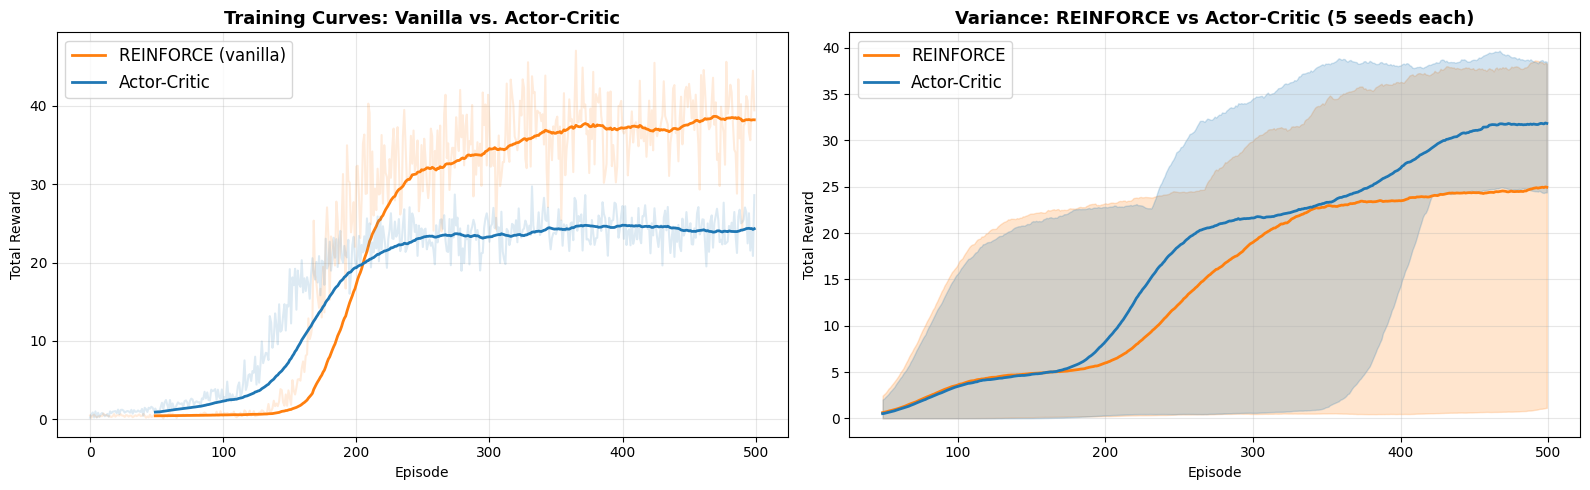


REINFORCE    — final reward:   24.9 +/- 13.2
Actor-Critic — final reward:   31.8 +/- 6.0


In [18]:
# Side-by-side: REINFORCE vs Actor-Critic
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overlaid training curves
ax = axes[0]
plot_rewards(rewards_reinforce, title='', ax=ax, color='tab:orange', label='REINFORCE (vanilla)')
plot_rewards(rewards_ac, title='', ax=ax, color='tab:blue', label='Actor-Critic')
ax.set_title('Training Curves: Vanilla vs. Actor-Critic', fontsize=13, fontweight='bold')
ax.legend(fontsize=12)

# Right: variance comparison (5 seeds of actor-critic)
ax = axes[1]
print('Training 5 seeds of Actor-Critic for variance comparison...')
ac_seed_rewards = {}
for seed in range(n_seeds):
    env_s = CrawlerEnv()
    _, _, rews = train_actor_critic(env_s, n_episodes=500, lr_actor=3e-4,
                                    seed=seed, verbose=False)
    ac_seed_rewards[seed] = rews

# Plot envelopes for both methods
window = 50
for method_rewards, color, label in [
    (seed_rewards, 'tab:orange', 'REINFORCE'),
    (ac_seed_rewards, 'tab:blue', 'Actor-Critic'),
]:
    min_len = min(len(r) for r in method_rewards.values())
    all_r = np.array([r[:min_len] for r in method_rewards.values()])
    smoothed = np.array([np.convolve(r, np.ones(window)/window, mode='valid') for r in all_r])
    x = np.arange(window-1, min_len)
    mean_r = smoothed.mean(axis=0)
    min_r = smoothed.min(axis=0)
    max_r = smoothed.max(axis=0)
    ax.fill_between(x, min_r, max_r, alpha=0.2, color=color)
    ax.plot(x, mean_r, color=color, linewidth=2, label=label)

ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Variance: REINFORCE vs Actor-Critic (5 seeds each)', fontsize=13, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
rf_finals = [np.mean(r[-50:]) for r in seed_rewards.values()]
ac_finals = [np.mean(r[-50:]) for r in ac_seed_rewards.values()]
print(f'\nREINFORCE    — final reward: {np.mean(rf_finals):6.1f} +/- {np.std(rf_finals):.1f}')
print(f'Actor-Critic — final reward: {np.mean(ac_finals):6.1f} +/- {np.std(ac_finals):.1f}')

In [16]:
# 10-second rollout of the Actor-Critic policy
env_eval_ac = CrawlerEnv()

def ac_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = actor_ac(obs_t)
        return mu.squeeze(0).cpu().numpy()

frames_ac, dist_ac, _ = eval_policy(env_eval_ac, ac_policy, 'Demo 7: Actor-Critic')
show_video(frames_ac, title=f'Actor-Critic — {dist_ac:.2f}m in 10s')

Demo 7: Actor-Critic: traveled 0.87m in 10s  (episode reward: 43.4)


---
## Final Comparison

Let's see all methods side-by-side: how far does the crawler get in 10 seconds?

In [ ]:
# ============================================================
# Final comparison: all methods, same crawler, 10 seconds
# ============================================================
plot_eval_comparison(eval_results)

---
## Summary

| Method | Actions | Key Property | Limitation |
|--------|---------|--------------|------------|
| **DQN** (reference) | 4 discrete | Stable off-policy learning | Discrete actions only |
| **REINFORCE** | 2D continuous | Works with any action space | High variance |
| **Actor-Critic** | 2D continuous | Baseline reduces variance | Can get unstable with large networks |

**What we showed:**
1. **REINFORCE handles continuous actions natively** — no discretization, no argmax
2. **Vanilla REINFORCE has high variance** — training curves vary wildly across seeds
3. **A learned baseline (critic) reduces variance** — smoother, more consistent training

**What comes next (Lecture 2):**
- Actor-Critic can get **unstable with larger networks** — motivates **trust regions** (TRPO)
- TRPO is hard to implement → **PPO** (clipped surrogate) as a practical solution
- **GAE** for better advantage estimation
- Scaling to complex bodies (Ant, Humanoid) with industrial-strength algorithms